# Assignment 9 - Use an AI-based tool to generate simple video animations.

# Model Used -
**Stable Diffusion Img-2-Video**
# APIs for Model Usage -
**Huggingface Transformers and Diffusers Pipeline**
# Model Details -
**This model uses a preexisting image as an input to generate a small video of continous frames.**

**Number of parameters - 860 Million**


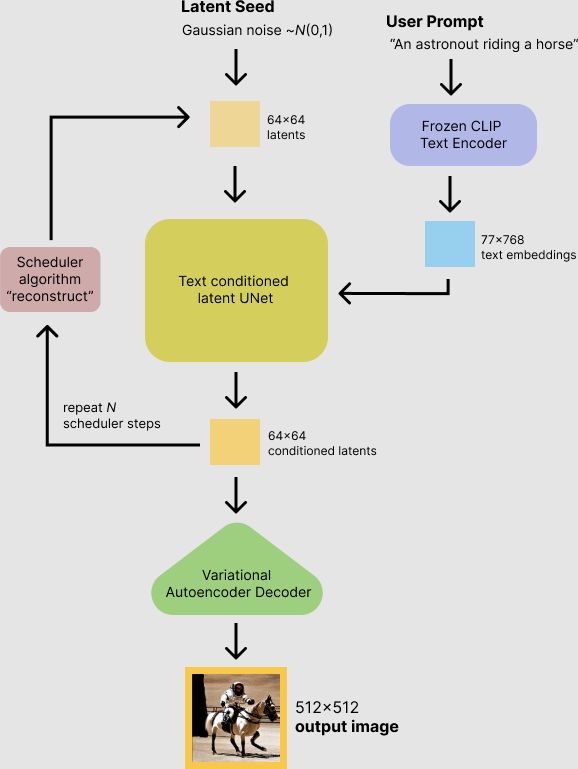



# Architecture of Stable Diffusion Model
# 3 Major components -
1. Latent Diffusion
2. U-Net
3. Text-Encoder

Source - https://medium.com/@onkarmishra/stable-diffusion-explained-1f101284484d

# Step 1. Installing the necessary libraries

In [ ]:
!pip install diffusers transformers accelerate torch torchvision safetensors

# Step 2. Loading the pipeline using the diffusers library, powered by HuggingFace for multimodal, state-of-the-art image and video generation models.

In [ ]:
import torch
from diffusers import StableVideoDiffusionPipeline
from diffusers.utils import export_to_video

pipe = StableVideoDiffusionPipeline.from_pretrained(
    "stabilityai/stable-video-diffusion-img2vid-xt",
    torch_dtype=torch.float16
)

pipe.enable_attention_slicing()
pipe.enable_model_cpu_offload()


pipe.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

It seems like you have activated model offloading by calling `enable_model_cpu_offload`, but are now manually moving the pipeline to GPU. It is strongly recommended against doing so as memory gains from offloading are likely to be lost. Offloading automatically takes care of moving the individual components vae, image_encoder, unet, scheduler, feature_extractor to GPU when needed. To make sure offloading works as expected, you should consider moving the pipeline back to CPU: `pipeline.to('cpu')` or removing the move altogether if you use offloading.


StableVideoDiffusionPipeline {
  "_class_name": "StableVideoDiffusionPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "stabilityai/stable-video-diffusion-img2vid-xt",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    "transformers",
    "CLIPVisionModelWithProjection"
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "unet": [
    "diffusers",
    "UNetSpatioTemporalConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKLTemporalDecoder"
  ]
}

# Step 3. Loading the image which is to be used as the conditional input.

In [ ]:
from PIL import Image
import requests

image = Image.open("/content/pezibear-maltese-1123016_1920.jpg").convert("RGB")
image = image.resize((1024, 576))

# Step 4. Clears unused cached GPU memory to reduce CUDA out-of-memory issues for use by PyTorch.

In [ ]:
import torch
torch.cuda.empty_cache()
torch.backends.cuda.matmul.allow_tf32 = True

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Step 5. Converting the image into moving frames using the diffusers pipeline

In [ ]:
frames = pipe(image, decode_chunk_size=8).frames[0]
export_to_video(frames, "generated.mp4", fps=7)

  0%|          | 0/25 [00:00<?, ?it/s]

'generated.mp4'